In [80]:
import numpy as np
import pandas as pd
import glob
from scipy.io import loadmat
from brainspace.gradient.gradient import GradientMaps
import func_plot as fp
import func_stats as fs
import nibabel as nib
from statsmodels.tools.tools import add_constant
import statsmodels.formula.api as smf
from matplotlib.colors import ListedColormap
"./BD-SCZ/RSFC_HC_SCZ_BD_noGSR/sub*.mat"

'./BD-SCZ/RSFC_HC_SCZ_BD_noGSR/sub*.mat'

## Regress out age and gender + correlation matrix between clinical scores and the mean yeo network gradient (1+3) and eccentricity matrix

Residualization complete.
Residualized data saved. Shape: (187, 43)
Correlation matrix saved. Shape: (28, 14)


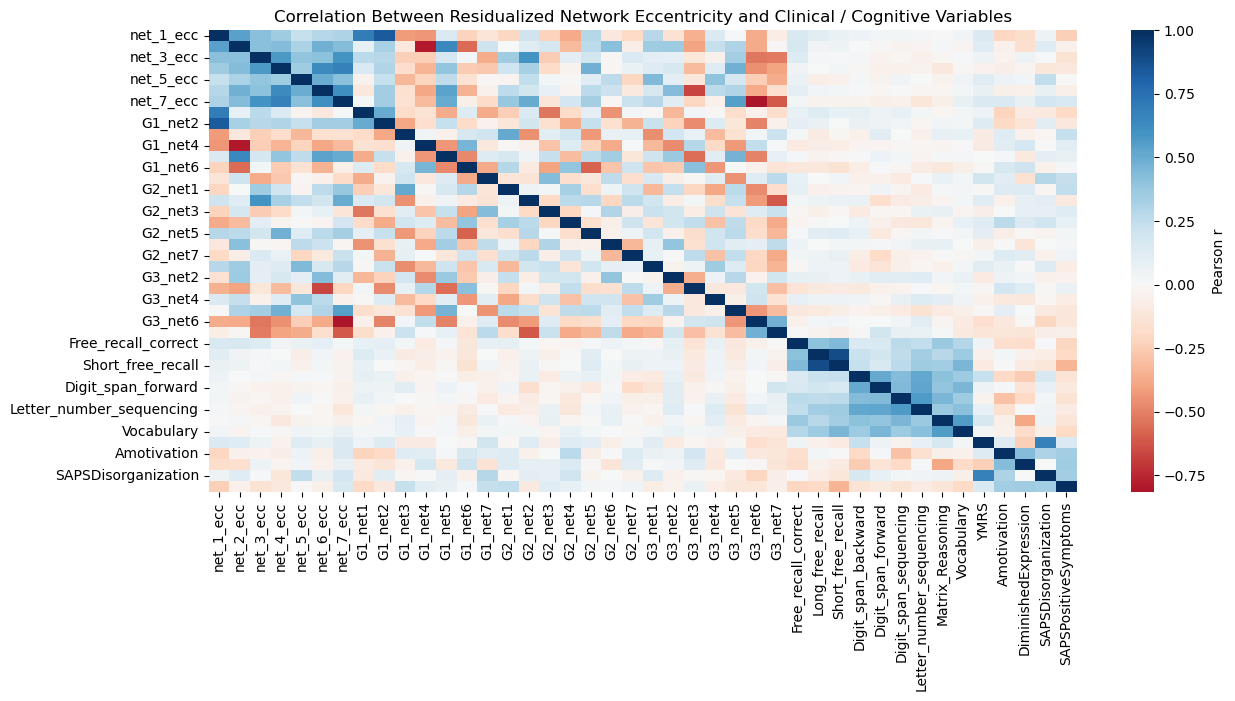

In [81]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------
# 1. Load the merged table
# ------------------------
df = pd.read_excel('Network_level_gradients_ecc_clinical.xlsx')

# Ensure participant ID is string
df['participant_id_num'] = df['participant_id_num'].astype(str)

# ------------------------
# 2. Define columns
# ------------------------
# Brain features: eccentricity + network-level gradients
brain_cols = [c for c in df.columns if 'net_' in c or 'G' in c]

# Clinical/cognitive variables
clinical_cols = [
    'Free_recall_correct', 'Long_free_recall', 'Short_free_recall',
    'Digit_span_backward', 'Digit_span_forward', 'Digit_span_sequencing',
    'Letter_number_sequencing', 'Matrix_Reasoning', 'Vocabulary',
    'YMRS', 'Amotivation', 'DiminishedExpression', 
    'SAPSDisorganization', 'SAPSPositiveSymptoms'
]

# Covariates
covariates = ['age', 'gender']

# ------------------------
# 3. Residualization function
# ------------------------
def residualize(df, target_cols, covariate_cols):
    """
    Regress out covariates from each column in target_cols.
    Returns a dataframe with residuals.
    """
    X = df[covariate_cols]
    X = sm.add_constant(X)
    resid_df = pd.DataFrame(index=df.index)
    
    for col in target_cols:
        if col not in df.columns:
            print(f"Warning: {col} not in dataframe, skipping.")
            continue
        y = df[col]
        model = sm.OLS(y, X, missing='drop').fit()
        resid_df[col] = model.resid
    resid_df['participant_id_num'] = df['participant_id_num']
    return resid_df

# ------------------------
# 4. Residualize brain and clinical variables
# ------------------------
brain_resid = residualize(df, brain_cols, covariates)
clinical_resid = residualize(df, clinical_cols, covariates)

# ------------------------
# 5. Merge residualized tables
# ------------------------
resid_df = pd.merge(brain_resid, clinical_resid, on='participant_id_num', how='inner')

# ------------------------
# 6. Correlation matrix
# ------------------------
# Compute correlations between brain features and clinical variables
corr_matrix = resid_df[brain_cols + clinical_cols].corr()

# Extract only brain vs clinical correlations
brain_vs_clinical = corr_matrix.loc[brain_cols, clinical_cols]

# ------------------------
# 7. Save residualized data and correlation matrix
# ------------------------
resid_df.to_excel('Residualized_Network_Gradients_Eccentricity.xlsx', index=False)
brain_vs_clinical.to_excel('Brain_vs_Clinical_Correlations.xlsx')

print("Residualization complete.")
print("Residualized data saved. Shape:", resid_df.shape)
print("Correlation matrix saved. Shape:", brain_vs_clinical.shape)

# -------------------------------------------
# 5. Plot heatmap
# -------------------------------------------
plt.figure(figsize=(14, 6))
sns.heatmap(corr_matrix.astype(float), annot=False, fmt=".2f",
            cmap="RdBu", center=0, cbar_kws={'label': 'Pearson r'})
plt.title("Correlation Between Residualized Network Eccentricity and Clinical / Cognitive Variables")
plt.show()


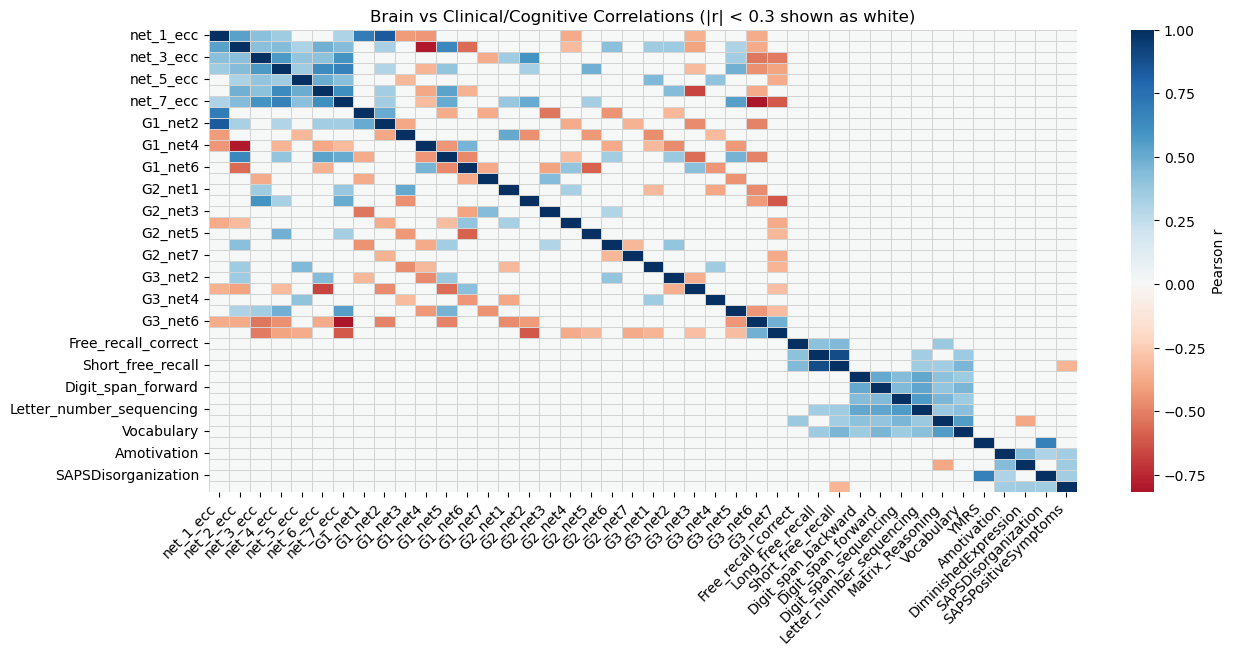

In [82]:
# Ensure numeric
corr_plot = corr_matrix.copy()

# Mask weak correlations (< 0.3) by setting them to 0
corr_plot_masked = corr_plot.mask(np.abs(corr_plot) < 0.3, 0)

# Plot heatmap with proper diverging colormap (white = 0)
plt.figure(figsize=(14, 6))
sns.heatmap(corr_plot_masked, annot=False, fmt=".2f",
            cmap="RdBu", center=0,  # red = positive, blue = negative
            cbar_kws={'label': 'Pearson r'},
            linewidths=0.5, linecolor='lightgrey')

plt.title("Brain vs Clinical/Cognitive Correlations (|r| < 0.3 shown as white)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()